In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error

In [2]:
df = pd.read_csv("Housing.csv")

df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.45857,5.682861,7.009188,4.09,23086.80050,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.64245,6.002900,6.730821,3.09,40173.07217,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.06718,5.865890,8.512727,5.13,36882.15940,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.24005,7.188236,5.586729,3.26,34310.24283,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.19723,5.040555,7.839388,4.23,26354.10947,6.309435e+05,USNS Raymond\nFPO AE 09386


In [3]:
print("Predictive Analytics Using Historical Data")
print("House Price Prediction using Linear Regression")

Predictive Analytics Using Historical Data
House Price Prediction using Linear Regression


In [4]:
print(df.shape)

print(df.info())

print(df.describe())

(5000, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB
None
       Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
count       5000.000000          5000.000000                5000.000000   
mean       68583.108984             5.977222                   6.987792   
std        10657.991214             0.991456                   1.0058

In [5]:
print(df.isnull().sum())

Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64


In [6]:
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.45857,5.682861,7.009188,4.09,23086.80050,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.64245,6.002900,6.730821,3.09,40173.07217,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.06718,5.865890,8.512727,5.13,36882.15940,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.24005,7.188236,5.586729,3.26,34310.24283,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.19723,5.040555,7.839388,4.23,26354.10947,6.309435e+05,USNS Raymond\nFPO AE 09386


In [7]:
df=df.drop(
'Address',
axis=1
)

In [8]:
print(
df.corr()
)

                              Avg. Area Income  Avg. Area House Age  \
Avg. Area Income                      1.000000            -0.002007   
Avg. Area House Age                  -0.002007             1.000000   
Avg. Area Number of Rooms            -0.011032            -0.009428   
Avg. Area Number of Bedrooms          0.019788             0.006149   
Area Population                      -0.016234            -0.018743   
Price                                 0.639734             0.452543   

                              Avg. Area Number of Rooms  \
Avg. Area Income                              -0.011032   
Avg. Area House Age                           -0.009428   
Avg. Area Number of Rooms                      1.000000   
Avg. Area Number of Bedrooms                   0.462695   
Area Population                                0.002040   
Price                                          0.335664   

                              Avg. Area Number of Bedrooms  Area Population  \
Avg. Area

In [9]:
X=df.drop(
'Price',
axis=1
)

y=df['Price']

In [10]:
print(X.head())

print(y.head())

   Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
0       79545.45857             5.682861                   7.009188   
1       79248.64245             6.002900                   6.730821   
2       61287.06718             5.865890                   8.512727   
3       63345.24005             7.188236                   5.586729   
4       59982.19723             5.040555                   7.839388   

   Avg. Area Number of Bedrooms  Area Population  
0                          4.09      23086.80050  
1                          3.09      40173.07217  
2                          5.13      36882.15940  
3                          3.26      34310.24283  
4                          4.23      26354.10947  
0    1.059034e+06
1    1.505891e+06
2    1.058988e+06
3    1.260617e+06
4    6.309435e+05
Name: Price, dtype: float64


In [11]:
X_train,X_test,y_train,y_test = train_test_split(

X,
y,

test_size=0.2,

random_state=42
)

In [12]:
model=LinearRegression()

model.fit(
X_train,
y_train
)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [13]:
y_pred=model.predict(
X_test
)

print(y_pred[:5])

[1308587.92718454 1237037.2295027  1243429.34023036 1228900.21368759
 1063320.90731602]


In [14]:
print(
"R2 Score:",
r2_score(
y_test,
y_pred
)
)

print(
"MAE:",
mean_absolute_error(
y_test,
y_pred
)
)

R2 Score: 0.9179971706985317
MAE: 80879.09722218332


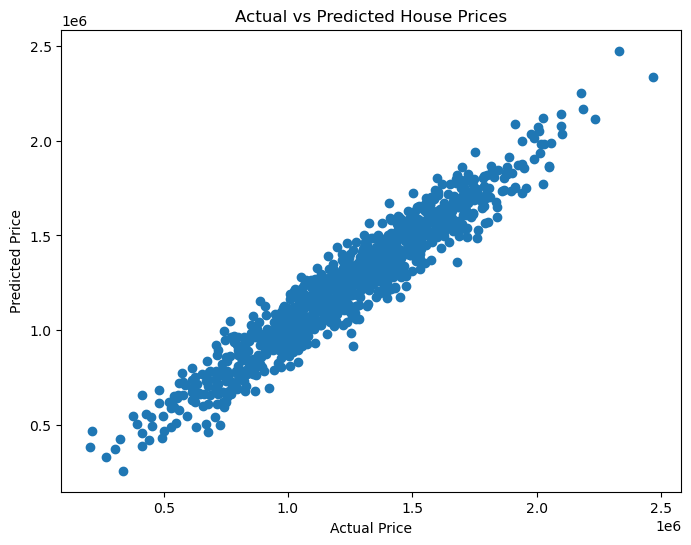

In [15]:
plt.figure(figsize=(8,6))

plt.scatter(
y_test,
y_pred
)

plt.xlabel(
"Actual Price"
)

plt.ylabel(
"Predicted Price"
)

plt.title(
"Actual vs Predicted House Prices"
)

plt.show()

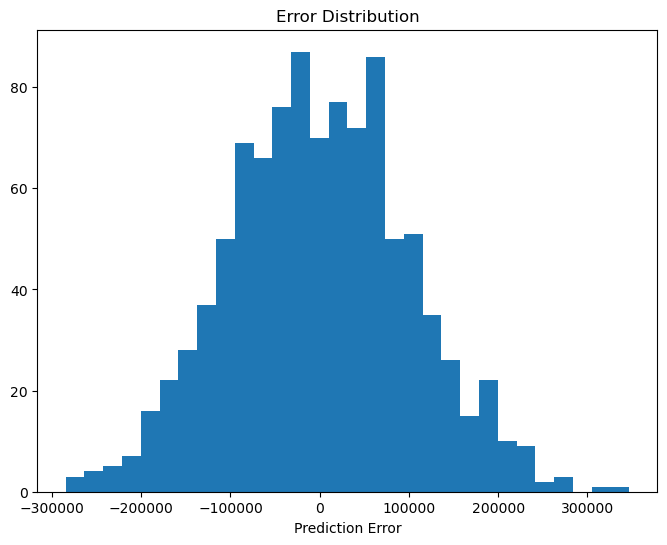

In [16]:
errors=y_test-y_pred

plt.figure(figsize=(8,6))

plt.hist(
errors,
bins=30
)

plt.xlabel(
"Prediction Error"
)

plt.title(
"Error Distribution"
)

plt.show()

In [17]:
new_house=[[80000,6,7,4,30000]]

prediction=model.predict(
new_house
)

print(
"Predicted House Price:"
)

print(prediction)

Predicted House Price:
[1390341.44345899]


C:\Users\kirta\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [18]:
print("""

Conclusion:

Historical housing data was used to build a predictive analytics model.

Data preprocessing and cleaning were performed.

Linear Regression was used to forecast house prices.

Model accuracy was evaluated using R² score and MAE.

Prediction visualization demonstrated strong forecasting capability.

""")



Conclusion:

Historical housing data was used to build a predictive analytics model.

Data preprocessing and cleaning were performed.

Linear Regression was used to forecast house prices.

Model accuracy was evaluated using R² score and MAE.

Prediction visualization demonstrated strong forecasting capability.


